# Entanglement sources analisys using Genqo

The work in this notebook is based on the paper "Entanglement distribution: To herald or not to herald" by Jeffrey H. Shapiro, Clark Embleton, J. Gabriel Richardson.
we will show that Genqo can be used to efficienntly simulate 

ZALM using Genqo

In [2]:
using Genqo
using Gabs
using QuantumOpticsBase
using LinearAlgebra
import LinearAlgebra: tr, dot, norm
using Plots
import Plots: plot, surface


bell fraction

First calculate the Bell-state probability:

In [3]:
function zalm_Pbell_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(8), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(4)),  [2,4,5,7])
    apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5,4,6])

    η = [ηR,ηR,ηT,ηT,ηT,ηT,ηR,ηR]
    Π = projector([:,:,1,1,0,0,:,:])
    st = project(st, Π; engine, η=η)

    ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
    ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
    ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
    ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

    real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
end

zalm_Pbell_numerical (generic function with 1 method)

In [4]:
function zalm_Pload_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(8), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(4)),  [2,4,5,7])
    apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5,4,6])

    η = [ηR,ηR,ηT,ηT,ηT,ηT,ηR,ηR]
    Π_S = projector([:,:,1,1,0,0,:,:])
    Π_A0 = projector([0,0,1,1,0,0,:,:])
    Π_B0 = projector([:,:,1,1,0,0,0,0])
    Π_S0 = projector([0,0,1,1,0,0,0,0])
    st_S = project(st, Π_S; engine, η=η)
    st_A0 = project(st, Π_A0; engine, η=η)
    st_B0 = project(st, Π_B0; engine, η=η)
    st_S0 = project(st, Π_S0; engine, η=η)

    tr(st_S) - tr(st_A0) - tr(st_B0) + tr(st_S0)
end


zalm_Pload_numerical (generic function with 1 method)

In [5]:
function zalm_bell_fraction_symbolic(μ::Real, ηR::Real, ηT::Real)::Real
        Ns  = (ηT*μ + 1) / (μ + 1)

        N′s = (ηR/Ns + (1 - ηR))^(-1)

        Pr_loadable = 1 - 2*(N′s^2)*(1 - (ηR*N′s)/(2*Ns))^2 + (N′s^4)*(1 - (ηR*N′s)/Ns)^2
        Pr_Bell = 2*N′s^4 * (
            2*(1 - N′s)^2
            - (2*ηR*(3*N′s^3 - 5*N′s^2 + 2*N′s)) / Ns
            + (ηR^2*(4*N′s^4 - 6*N′s^3 + 2*N′s^2)) / Ns^2
        ) + (ηR^2 * N′s^8) / (2*Ns^2)
        
        return Pr_Bell / Pr_loadable
    end

zalm_bell_fraction_symbolic (generic function with 1 method)

Fidelity

fidelity is p phi- over pbell

In [6]:
function zalm_bell_fidelity_numerical(μ::Float64,ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
        st = eprstate(QuadBlockBasis(8), asinh(√μ), 0.)
        apply!(st, modeswap(QuadBlockBasis(4)),  [2,4,5,7])
        apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5,4,6])

        η = [ηR,ηR,ηT,ηT,ηT,ηT,ηR,ηR]
        Π = projector([:,:,1,1,0,0,:,:])
        st = project(st, Π; engine, η=η)

        ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
        ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
        ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
        ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

       real(dot(ψ⁺', st, ψ⁺)) / real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
    end

zalm_bell_fidelity_numerical (generic function with 1 method)

In [7]:
 function zalm_bell_fidelity_symbolic(μ::Real, ηR::Real, ηT::Real)::Real

        Ns  = (ηT*μ + 1) / (μ + 1)
        
        N′s = (ηR/Ns + (1 - ηR))^(-1)
        
        Pr_psi_minus = (N′s^4 / 2) * (
            2*(1 - N′s)^2
            - (2*ηR*(3*N′s^3 - 5*N′s^2 + 2*N′s)) / Ns
            + (ηR^2*(5*N′s^4 - 6*N′s^3 + 2*N′s^2)) / Ns^2  
        )
        Pr_Bell = 2*N′s^4 * (
            2*(1 - N′s)^2
            - (2*ηR*(3*N′s^3 - 5*N′s^2 + 2*N′s)) / Ns
            + (ηR^2*(4*N′s^4 - 6*N′s^3 + 2*N′s^2)) / Ns^2
        ) + (ηR^2 * N′s^8) / (2*Ns^2)

        return Pr_psi_minus / Pr_Bell
    end

zalm_bell_fidelity_symbolic (generic function with 1 method)

SPDC unheralded source

bell fraction

In [8]:
 function spdc_Pload_numerical(μ::Float64, ηR::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(2)), [2,4])
    η = [ηR,ηR,ηR,ηR]
    Π_A0 = projector([0,0,:,:])
    Π_B0 = projector([:,:,0,0])
    Π_S0 = projector([0,0,0,0])

    st_A0 = project(st, Π_A0; engine, η=η)
    st_B0 = project(st, Π_B0; engine, η=η)
    st_S0 = project(st, Π_S0; engine, η=η)

    1 - tr(st_A0) - tr(st_B0) + tr(st_S0)
end

spdc_Pload_numerical (generic function with 1 method)

In [9]:
function spdc_Pbell_numerical(μ::Float64, ηR::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(2)), [2,4])
    η = [ηR,ηR,ηR,ηR]
    Π = projector([:,:,:,:])
    st = project(st, Π; engine, η=η)

    ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
    ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
    ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
    ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

    real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
end

spdc_Pbell_numerical (generic function with 1 method)

In [10]:
function spdc_bell_fraction_symbolic(μ::Float64, ηR::Float64)::Float64
        G = μ + 1 
        Pr_loadable = 1 - 2/(ηR*μ + 1)^2 + 1/(ηR*(2 - ηR)*μ + 1)^2
        Pr_Bell = (ηR^2 * μ * (3*G - 1 + ηR*(ηR - 2)*μ) + 3*(ηR*(ηR - 1)*μ)^2) / ((ηR*(ηR - 2)*μ - 1)^4)
        return Pr_Bell / Pr_loadable
    end


spdc_bell_fraction_symbolic (generic function with 1 method)

fidelity

In [11]:
function spdc_bell_fidelity_numerical(μ::Float64, ηR::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(2)), [2,4])
    η = [ηR,ηR,ηR,ηR]
    Π = projector([:,:,:,:])
    st = project(st, Π; engine, η=η)
    

    ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
    ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
    ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
    ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

    real(dot(ψ⁺', st, ψ⁺))/ real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
end

spdc_bell_fidelity_numerical (generic function with 1 method)

In [12]:
function spdc_bell_fidelity_symbolic(μ::Float64, ηR::Float64)::Float64
        G = μ + 1 
        Pr_psi_minus = (ηR^2 * μ * (3*G - 1 + ηR*(ηR - 2)*μ)) / ((ηR*(ηR - 2)*μ - 1)^4)
        Pr_Bell = (ηR^2 * μ * (3*G - 1 + ηR*(ηR - 2)*μ) + 3*(ηR*(ηR - 1)*μ)^2) / ((ηR*(ηR - 2)*μ - 1)^4)
        return Pr_psi_minus / Pr_Bell
    end

spdc_bell_fidelity_symbolic (generic function with 1 method)

Chahine et al source

In [13]:
function chahine_Pbell_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.) ⊗ vacuumstate(QuadBlockBasis(2))
    apply!(st, modeswap(QuadBlockBasis(2)), [2,4])
    apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5, 4,6])

    η = [ηT,ηT,ηR,ηR,ηR,ηR]
    Π_S = projector([1,1,:,:,:,:])

    st = project(st, Π_S; engine=engine, η=η)
    ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
    ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
    ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
    ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

    real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
end

chahine_Pbell_numerical (generic function with 1 method)

In [14]:
 function chahine_Pload_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
        st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.) ⊗ vacuumstate(QuadBlockBasis(2))
        apply!(st, modeswap(QuadBlockBasis(2)),[2,4])
        apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5, 4,6])

        η = [ηT,ηT,ηR,ηR,ηR,ηR]
        Π_S = projector([1,1,:,:,:,:])
        Π_A0 = projector([1,1,0,0,:,:])
        Π_B0 = projector([1,1,:,:,0,0])
        Π_S0 = projector([1,1,0,0,0,0])

        st_S = project(st, Π_S; engine=engine, η=η)
        st_A0 = project(st, Π_A0; engine=engine, η=η)
        st_B0 = project(st, Π_B0; engine=engine, η=η)
        st_S0 = project(st, Π_S0; engine=engine, η=η)

        tr(st_S) - tr(st_A0) - tr(st_B0) + tr(st_S0)
    end

chahine_Pload_numerical (generic function with 1 method)

In [15]:
    function chahine_bell_faction_symbolic(μ::Float64, ηR::Float64, ηT::Float64)::Float64
        Ns  = (ηT*μ + 1) / (μ + 1)
        N′s = (ηR/Ns + (1 - ηR))^(-1)
        Ñs = 2*N′s/(N′s + 1)
        Pr_loadable = 1 - 2*(Ñs^2)*(1 - (ηR*Ñs)/(2*Ns))^2 + (N′s^2)*(1 - (ηR*N′s)/Ns)^2
        
        Pr_Bell = N′s^2 * (
            3*(1 - N′s)^2 / 2
            - (3*ηR*N′s*(1 - 2*N′s)*(1 - N′s)) / Ns
            + (ηR^2*N′s^2*((1 - 2*N′s)^2 + 2*(1 - 3*N′s)*(1 - N′s))) / (2*Ns^2)
        )
        return Pr_Bell / Pr_loadable
    end

chahine_bell_faction_symbolic (generic function with 1 method)

Fidelity

In [16]:
  function chahine_bell_fidelity_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
        st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.) ⊗ vacuumstate(QuadBlockBasis(2))
        apply!(st, modeswap(QuadBlockBasis(2)), [2,4])
        apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5, 4,6])

        η = [ηT,ηT,ηR,ηR,ηR,ηR]
        Π = projector([1,1,:,:,:,:])
        st = project(st, Π; engine=engine, η=η)

        ψ⁺ = (clicks([1,0,0,1]) + clicks([0,1,1,0])) / √2
        ψ⁻ = (clicks([1,0,0,1]) - clicks([0,1,1,0])) / √2
        ϕ⁺ = (clicks([1,0,1,0]) + clicks([0,1,0,1])) / √2
        ϕ⁻ = (clicks([1,0,1,0]) - clicks([0,1,0,1])) / √2

       real(dot(ψ⁺', st, ψ⁺)) / real(dot(ψ⁺', st, ψ⁺) + dot(ψ⁻', st, ψ⁻) + dot(ϕ⁺', st, ϕ⁺) + dot(ϕ⁻', st, ϕ⁻))
    end

chahine_bell_fidelity_numerical (generic function with 1 method)

In [17]:
function chahine_bell_fidelity_symbolic(μ::Real , ηR::Real , ηT::Real)::Real
        Ns  = (ηT*μ + 1) / (μ + 1)
        N′s = (ηR/Ns + (1 - ηR))^(-1)
        
        Pr_psi_minus = N′s^2 * (
            (1 - N′s)^2 / 2
            - (ηR*N′s*(1 - 2*N′s)*(1 - N′s)) / Ns
            + (ηR^2*N′s^2*(1 - 2*N′s)^2) / (2*Ns^2)
        )
    
        Pr_Bell = N′s^2 * (
            3*(1 - N′s)^2 / 2
            - (3*ηR*N′s*(1 - 2*N′s)*(1 - N′s)) / Ns
            + (ηR^2*N′s^2*((1 - 2*N′s)^2 + 2*(1 - 3*N′s)*(1 - N′s))) / (2*Ns^2)
        )
    
        return Pr_psi_minus / Pr_Bell
    end


chahine_bell_fidelity_symbolic (generic function with 1 method)

Compare all sources.

In [18]:
function plot_bell_state_fraction_comparison()
    engine_spdc = HybridProjectionEngine(4)
    engine_zalm = HybridProjectionEngine(8)
    engine_chahine = HybridProjectionEngine(6)
    μ = logrange(1e-4, 1.5, 100)

    ηR = 0.01
    ηT = 0.9

    Bfraction_zalm_numerical = zalm_Pbell_numerical.(μ, ηR, ηT; engine=engine_zalm) ./ zalm_Pload_numerical.(μ, ηR, ηT; engine=engine_zalm)
    Bfraction_zalm_symbolic = zalm_bell_fraction_symbolic.(μ, ηR, ηT)

    Bfraction_chahine_numerical = chahine_Pbell_numerical.(μ, ηR, ηT; engine=engine_chahine) ./ chahine_Pload_numerical.(μ, ηR, ηT; engine=engine_chahine)
    Bfraction_chahine_symbolic = chahine_bell_faction_symbolic.(μ, ηR, ηT)

    Bfraction_spdc_symbolic = spdc_bell_fraction_symbolic.(μ, ηR)
    Bfraction_spdc_numerical = spdc_Pbell_numerical.(μ, 0.01; engine=engine_spdc) ./ spdc_Pload_numerical.(μ, 0.01; engine=engine_spdc)


    Plots.plot(μ, Bfraction_zalm_symbolic, label = "ZALM analytic", xlabel = "Mean Photon Number",ylabel = "Bell-state Fraction", legend = :bottomleft,color = 1)
    Plots.plot!(μ, Bfraction_chahine_symbolic, label = "Chahine analytic", color = 3)
    Plots.plot!(μ, Bfraction_spdc_symbolic, label = "SPDC analytic", color = 4)
    Plots.plot!(μ, Bfraction_zalm_numerical, label = "ZALM numerical (Genqo v2.0)", color = 2, linestyle = :dash)
    Plots.plot!(μ, Bfraction_chahine_numerical, label = "Chahine numerical (Genqo v2.0)", color = 5, linestyle = :dash)
    Plots.plot!(μ, Bfraction_spdc_numerical, label = "SPDC numerical (Genqo v2.0)", color = 6, linestyle = :dash)
    Plots.title!("Bell-state Fraction Comparison for: \$\\eta_R = $(ηR),\\; \\eta_T = $(ηT)\$")
end


plot_bell_state_fraction_comparison (generic function with 1 method)

In [19]:
function plot_bell_state_fidelity_comparison()
    engine_spdc = HybridProjectionEngine(4)
    engine_zalm = HybridProjectionEngine(8)
    engine_chahine = HybridProjectionEngine(6)
    μ = logrange(1e-4, 10, 100)

    ηR = 0.01
    ηT = 0.9

    fidelity_zalm_numerical = zalm_bell_fidelity_numerical.(μ, ηR, ηT; engine=engine_zalm)
    fidelity_zalm_symbolic = zalm_bell_fidelity_symbolic.(μ, ηR, ηT)

    fidelity_chahine_numerical = chahine_bell_fidelity_numerical.(μ, ηR, ηT; engine=engine_chahine)
    fidelity_chahine_symbolic = chahine_bell_fidelity_symbolic.(μ, ηR, ηT)

    fidelity_spdc_symbolic = spdc_bell_fidelity_symbolic.(μ, ηR)
    fidelity_spdc_numerical = spdc_bell_fidelity_numerical.(μ, 0.01; engine=engine_spdc)


    Plots.plot(μ, fidelity_zalm_symbolic, label = "ZALM analytic", xlabel = "Mean Photon Number",ylabel = "Bell-state Fidelity", legend = :topright,color = 1)
    Plots.plot!(μ, fidelity_chahine_symbolic, label = "Chahine analytic", color = 3)
    Plots.plot!(μ, fidelity_spdc_symbolic, label = "SPDC analytic", color = 4)
    Plots.plot!(μ, fidelity_zalm_numerical, label = "ZALM numerical (Genqo v2.0)", color = 2, linestyle = :dash)
    Plots.plot!(μ, fidelity_chahine_numerical, label = "Chahine numerical (Genqo v2.0)", color = 5, linestyle = :dash)
    Plots.plot!(μ, fidelity_spdc_numerical, label = "SPDC numerical (Genqo v2.0)", color = 6, linestyle = :dash)
    Plots.title!("Bell-state Fidelity Comparison for: \$\\eta_R = $(ηR),\\; \\eta_T = $(ηT)\$")
end
@time plot_bell_state_fidelity_comparison()
savefig("myplot.png")

 14.342458 seconds (28.80 M allocations: 1.464 GiB, 5.08% gc time, 98.10% compilation time: 12% of which was recompilation)


"/home/jorge/vscode/Genqo.jl/docs/tutorial/myplot.png"

Now probability Hnm for zalm and chahine source

In [20]:
function zalm_PHeralded_symbolic(μ::Float64, ηR::Float64, ηT::Float64)::Float64
    PH = (4 * (ηT * μ)^2)/ ((ηT * μ) + 1)^6    
    return PH
end

zalm_PHeralded_symbolic (generic function with 1 method)

In [21]:
function zalm_PHeralded_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(8), asinh(√μ), 0.)
    apply!(st, modeswap(QuadBlockBasis(4)), [2,4, 5,7])
    apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5, 4,6])

    η = [ηR,ηR,ηT,ηT,ηT,ηT,ηR,ηR]
    Π = projector([:,:,0,1,1,0,:,:])
    st = project(st, Π; engine=engine, η=η)

    return 4*tr(st)
end

zalm_PHeralded_numerical (generic function with 1 method)

Hnm probability chahine

In [22]:
function chahine_PHeralded_symbolic(μ::Float64, ηR::Float64, ηT::Float64)::Float64
    PH = ((ηT * μ)^2)/ ((ηT * μ) + 1)^4    
    return PH
end

chahine_PHeralded_symbolic (generic function with 1 method)

In [23]:
function chahine_PHeralded_numerical(μ::Float64, ηR::Float64, ηT::Float64; engine::HybridProjectionEngine)
    st = eprstate(QuadBlockBasis(4), asinh(√μ), 0.) ⊗ vacuumstate(QuadBlockBasis(2))
    apply!(st, modeswap(QuadBlockBasis(2)),[2,4])
    apply!(st, beamsplitter(QuadBlockBasis(4), 0.5), [3,5, 4,6])

    η = [ηT,ηT,ηR,ηR,ηR,ηR]
    Π = projector([1,1,:,:,:,:])
    st = project(st, Π; engine=engine, η=η)

    return tr(st)
end

chahine_PHeralded_numerical (generic function with 1 method)

compare Heralding probability.

In [24]:
function plot_Pherald_comparison()
    engine_zalm = HybridProjectionEngine(8)
    engine_chahine = HybridProjectionEngine(6)
    μ = logrange(1e-4, 1.5, 100)

    ηR = 0.01
    ηT = 0.9

    PH_zalm_numerical = zalm_PHeralded_numerical.(μ, ηR, ηT; engine=engine_zalm)
    PH_zalm_symbolic = zalm_PHeralded_symbolic.(μ, ηR, ηT)

    PH_chahine_numerical = chahine_PHeralded_numerical.(μ, ηR, ηT; engine=engine_chahine)
    PH_chahine_symbolic = chahine_PHeralded_symbolic.(μ, ηR, ηT)

    Plots.plot(μ, PH_zalm_symbolic, label = "ZALM analytic", xlabel = "Mean Photon Number",ylabel = "Heralding Probability", legend = :bottomright,color = 1)
    Plots.plot!(μ, PH_chahine_symbolic, label = "Chahine analytic", color = 3)
    Plots.plot!(μ, PH_zalm_numerical, label = "ZALM numerical (Genqo v2.0)", color = 2, linestyle = :dash)
    Plots.plot!(μ, PH_chahine_numerical, label = "Chahine numerical (Genqo v2.0)", color = 5, linestyle = :dash)
    Plots.title!("Heralding Probability Comparison for: \$\\eta_R = $(ηR),\\; \\eta_T = $(ηT)\$")
end
@time plot_Pherald_comparison()
savefig("myplot.png")
savefig("myplot.svg")

  0.044194 seconds (42.12 k allocations: 20.980 MiB, 59.34% compilation time)


"/home/jorge/vscode/Genqo.jl/docs/tutorial/myplot.svg"

Now calculate rate of distributed entanglement

In [25]:
function zalm_q_symbolic(μ::Float64, ηT::Float64)::Float64
    q = (2 * ηT * μ) / (ηT * μ + 1)^3
    return q
end

zalm_q_symbolic (generic function with 1 method)

In [26]:
function chahine_q_symbolic(μ::Float64, ηT::Float64)::Float64
    q = (ηT * μ) / (ηT * μ + 1)^2
    return q
end

chahine_q_symbolic (generic function with 1 method)

In [27]:
using SpecialFunctions: binomial

function pmf_zP(N_I::Int, q::Float64)
    return [binomial(N_I, ℓ) * q^ℓ * (1 - q)^(N_I - ℓ) for ℓ in 0:N_I]
end

function p_k_array(N_I::Int, q::Float64)
    Pz = pmf_zP(N_I, q)
    p = zeros(Float64, N_I + 1)
    for k in 0:N_I
        term = Pz[k + 1]
        tail = sum(Pz[(k + 2):end])
        p[k + 1] = term * (term + 2 * tail)
    end
    return p
end

function E_H(p, N_M::Integer)
    N_I = length(p) - 1
    k = collect(0:N_I)
    N_M_eff = clamp(Int(N_M), 0, N_I)
    if N_M_eff <= 0
        return 0.0
    end
    return sum(k[1:N_M_eff] .* p[1:N_M_eff]) + N_M_eff * sum(p[(N_M_eff + 1):end])
end


E_H (generic function with 1 method)

In [28]:
function zalm_rate_dist_entanglement_numerical(μ::Float64, ηR::Float64, ηT::Float64, Rp::Float64, N_I::Integer, N_M; engine::HybridProjectionEngine)
    q = sqrt(zalm_PHeralded_numerical(μ, ηR, ηT; engine=engine))
    p_array = p_k_array(Int(N_I), q)
    EH = E_H(p_array, N_M)
    PBell = (zalm_Pbell_numerical(μ, ηR, ηT; engine=engine) ./ zalm_PHeralded_numerical(μ, ηR, ηT; engine=engine)) .* 4
    F = zalm_bell_fidelity_numerical(μ, ηR, ηT; engine=engine)

    return Rp * EH * PBell * F
end
function zalm_Pbell_symbolic(μ::Float64, ηR::Float64, ηT::Float64)
    Ns  = (ηT*μ + 1) / (μ + 1)
    N′s = (ηR/Ns + (1 - ηR))^(-1)
    Pr_Bell = 2*N′s^4 * (
        2*(1 - N′s)^2
        - (2*ηR*(3*N′s^3 - 5*N′s^2 + 2*N′s)) / Ns
        + (ηR^2*(4*N′s^4 - 6*N′s^3 + 2*N′s^2)) / Ns^2
    ) + (ηR^2 * N′s^8) / (2*Ns^2)
    
    return Pr_Bell
end
function zalm_Pload_symbolic(μ::Float64, ηR::Float64, ηT::Float64)
        Ns  = (ηT*μ + 1) / (μ + 1)

        N′s = (ηR/Ns + (1 - ηR))^(-1)

        Pr_loadable = 1 - 2*(N′s^2)*(1 - (ηR*N′s)/(2*Ns))^2 + (N′s^4)*(1 - (ηR*N′s)/Ns)^2
    return Pr_loadable
end
    
function zalm_rate_dist_entanglement_symbolic(μ::Float64, ηR::Float64, ηT::Float64, Rp, N_I::Integer, N_M::Integer)
    Pbell = zalm_Pbell_symbolic(μ, ηR, ηT)
    F = zalm_bell_fidelity_symbolic(μ, ηR, ηT)
    q = zalm_q_symbolic(μ, ηT)
    p_array = p_k_array(N_I, q)
    EH = E_H(p_array, N_M)

    return Rp * EH * F * Pbell
end  

zalm_rate_dist_entanglement_symbolic (generic function with 1 method)

In [29]:
function chahine_rate_dist_entanglement_numerical(μ::Float64, ηR::Float64, ηT::Float64, Rp::Float64, N_I::Integer, N_M; engine::HybridProjectionEngine)
    q = sqrt(chahine_PHeralded_numerical(μ, ηR, ηT; engine=engine))
    p_array = p_k_array(Int(N_I), q)
    EH = E_H(p_array, N_M)
    PBell = (chahine_Pbell_numerical(μ, ηR, ηT; engine=engine) ./ chahine_PHeralded_numerical(μ, ηR, ηT; engine=engine))
    F = chahine_bell_fidelity_numerical(μ, ηR, ηT; engine=engine)

    return Rp * EH * PBell * F
end

function chahine_Pbell_symbolic(μ::Float64, ηR::Float64, ηT::Float64)
    Ns  = (ηT*μ + 1) / (μ + 1)
    N′s = (ηR/Ns + (1 - ηR))^(-1)
    Ñs = 2*N′s/(N′s + 1)
    
    Pr_Bell = N′s^2 * (
        3*(1 - N′s)^2 / 2
        - (3*ηR*N′s*(1 - 2*N′s)*(1 - N′s)) / Ns
        + (ηR^2*N′s^2*((1 - 2*N′s)^2 + 2*(1 - 3*N′s)*(1 - N′s))) / (2*Ns^2)
    )
    return Pr_Bell
end

function chahine_Pload_symbolic(μ::Float64, ηR::Float64, ηT::Float64)
        Ns  = (ηT*μ + 1) / (μ + 1)
        N′s = (ηR/Ns + (1 - ηR))^(-1)
        Ñs = 2*N′s/(N′s + 1)
        Pr_loadable = 1 - 2*(Ñs^2)*(1 - (ηR*Ñs)/(2*Ns))^2 + (N′s^2)*(1 - (ηR*N′s)/Ns)^2
    return Pr_loadable
end
function chahine_rate_dist_entanglement_symbolic(μ::Float64, ηR::Float64, ηT::Float64, Rp, N_I::Integer, N_M::Integer)
    Pbell = chahine_Pbell_symbolic(μ, ηR, ηT)
    F = chahine_bell_fidelity_symbolic(μ, ηR, ηT)
    q = chahine_q_symbolic(μ, ηT)
    p_array = p_k_array(N_I, q)
    EH = E_H(p_array, N_M)

    return Rp * EH * F * Pbell
end 


chahine_rate_dist_entanglement_symbolic (generic function with 1 method)

In [30]:
function spdc_rate_dist_entanglement_numerical(μ::Float64, ηR::Float64, Rp::Float64, N_M; engine::HybridProjectionEngine)
    PBell = spdc_Pbell_numerical(μ, ηR; engine=engine)
    F = spdc_bell_fidelity_numerical(μ, ηR; engine=engine)
    return Rp * N_M * PBell * F
end
function spdc_Pbell_symbolic(μ::Float64, ηR::Float64)::Float64
    G = μ + 1 
    Pr_Bell = (ηR^2 * μ * (3*G - 1 + ηR*(ηR - 2)*μ) + 3*(ηR*(ηR - 1)*μ)^2) / ((ηR*(ηR - 2)*μ - 1)^4)
    return Pr_Bell
end
function spdc_rate_dist_entanglement_symbolic(μ::Float64, ηR::Float64, Rp::Float64, N_M::Int)
    PBell = spdc_Pbell_symbolic(μ, ηR)
    F = spdc_bell_fidelity_symbolic(μ, ηR)
    return Rp * N_M * PBell * F
end

spdc_rate_dist_entanglement_symbolic (generic function with 1 method)

In [31]:
function plot_PHerald_comparison()
    engine_zalm = HybridProjectionEngine(8)
    engine_chahine = HybridProjectionEngine(6)
    μ = logrange(1e-4, 1.5, 100)

    ηR = 0.01
    ηT = 0.9

    PH_zalm_numerical = zalm_PHeralded_numerical.(μ, ηR, ηT; engine=engine_zalm)
    PH_zalm_symbolic = zalm_PHeralded_symbolic.(μ, ηR, ηT)

    PH_chahine_numerical = chahine_PHeralded_numerical.(μ, ηR, ηT; engine=engine_chahine)
    PH_chahine_symbolic = chahine_PHeralded_symbolic.(μ, ηR, ηT)

    Plots.plot(μ, PH_zalm_symbolic, label = "ZALM analytic", xlabel = "Mean Photon Number",ylabel = "Heralding Probability", legend = :bottomright,color = 1)
    Plots.plot!(μ, PH_chahine_symbolic, label = "Chahine analytic", color = 3)
    Plots.plot!(μ, PH_zalm_numerical, label = "ZALM numerical (Genqo v2.0)", color = 2, linestyle = :dash)
    Plots.plot!(μ, PH_chahine_numerical, label = "Chahine numerical (Genqo v2.0)", color = 5, linestyle = :dash)
    Plots.title!("Heralding Probability Comparison for: \$\\eta_R = $(ηR),\\; \\eta_T = $(ηT)\$")
end

@time plot_PHerald_comparison()
savefig("myplot.png")
savefig("myplot.svg")

  0.015867 seconds (27.62 k allocations: 20.357 MiB)


"/home/jorge/vscode/Genqo.jl/docs/tutorial/myplot.svg"

  0.317420 seconds (369.38 k allocations: 152.131 MiB, 8.66% gc time, 8.26% compilation time: <1% of which was recompilation)


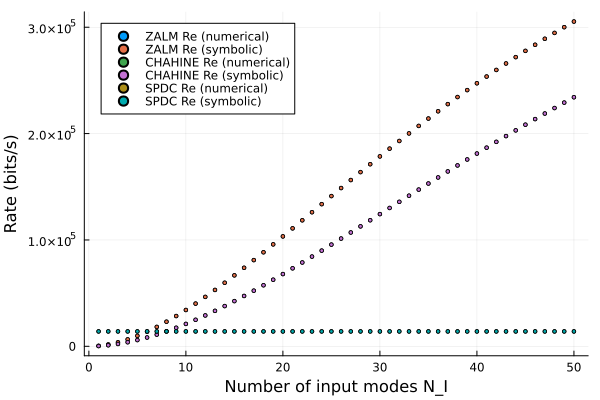

In [32]:
function plot_rate_dist_entanglement()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ_zalm = 0.0173
    μ_chahine = 0.0263
    μ_spdc = 0.00694
    ηR = 0.01
    ηT = 0.9
    Rp = 10e9
    N_I = collect(1:50)
    N_M = 1

    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ_zalm, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine)
    zalm_rates_symbolic = zalm_rate_dist_entanglement_symbolic.(μ_zalm, ηR, ηT, Rp, N_I, N_M)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ_chahine, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)
    chahine_rates_symbolic = chahine_rate_dist_entanglement_symbolic.(μ_chahine, ηR, ηT, Rp, N_I, N_M)
    
    spdc_rates_numerical = [spdc_rate_dist_entanglement_numerical(μ_spdc, ηR, Rp, N_M; engine=spdc_engine) for _ in N_I]
    spdc_rates_symbolic = [spdc_rate_dist_entanglement_symbolic(μ_spdc, ηR, Rp, N_M) for _ in N_I]

    Plots.plot(N_I, zalm_rates_numerical, seriestype=:scatter, label="ZALM Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", legend=:topleft,color=1, markersize=2)
    Plots.plot!(N_I, zalm_rates_symbolic, seriestype=:scatter, label="ZALM Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)",color=2, markersize=2)
    Plots.plot!(N_I, chahine_rates_numerical, seriestype=:scatter, label="CHAHINE Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=3, markersize=2)
    Plots.plot!(N_I, chahine_rates_symbolic, seriestype=:scatter, label="CHAHINE Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=4, markersize=2)
    Plots.plot!(N_I, spdc_rates_numerical, seriestype=:scatter, label="SPDC Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=5, markersize=2)
    Plots.plot!(N_I, spdc_rates_symbolic, seriestype=:scatter, label="SPDC Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=6, markersize=2)
end
@time plot_rate_dist_entanglement()


Now add memories.

  0.216463 seconds (331.88 k allocations: 140.011 MiB, 21.10% gc time)


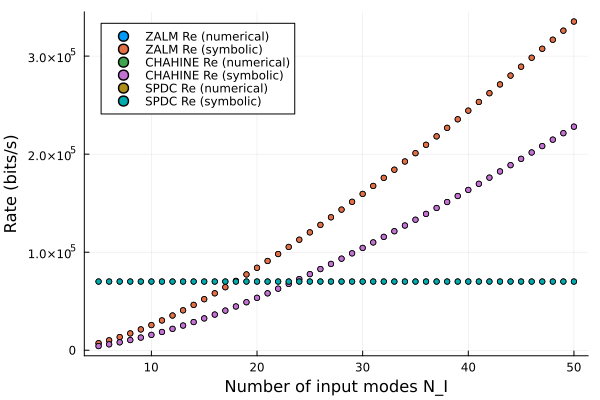

In [33]:
function plot_rate_dist_entanglement_with_Nm()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ_zalm = 0.0173
    μ_chahine = 0.0263
    μ_spdc = 0.00694
    ηR = 0.01
    ηT = 0.75
    Rp = 10e9
    N_I = collect(5:50)
    N_M = 5

    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ_zalm, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine)
    zalm_rates_symbolic = zalm_rate_dist_entanglement_symbolic.(μ_zalm, ηR, ηT, Rp, N_I, N_M)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ_chahine, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)
    chahine_rates_symbolic = chahine_rate_dist_entanglement_symbolic.(μ_chahine, ηR, ηT, Rp, N_I, N_M)
    
    spdc_rates_numerical = [spdc_rate_dist_entanglement_numerical(μ_spdc, ηR, Rp, N_M; engine=spdc_engine) for _ in N_I]
    spdc_rates_symbolic = [spdc_rate_dist_entanglement_symbolic(μ_spdc, ηR, Rp, N_M) for _ in N_I]

    Plots.plot(N_I, zalm_rates_numerical, seriestype=:scatter, label="ZALM Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", legend=:topleft,color=1, markersize=3)
    Plots.plot!(N_I, zalm_rates_symbolic, seriestype=:scatter, label="ZALM Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)",color=2, markersize=3)
    Plots.plot!(N_I, chahine_rates_numerical, seriestype=:scatter, label="CHAHINE Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=3, markersize=3)
    Plots.plot!(N_I, chahine_rates_symbolic, seriestype=:scatter, label="CHAHINE Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=4, markersize=3)
    Plots.plot!(N_I, spdc_rates_numerical, seriestype=:scatter, label="SPDC Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=5, markersize=3)
    Plots.plot!(N_I, spdc_rates_symbolic, seriestype=:scatter, label="SPDC Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=6, markersize=3)
end
@time plot_rate_dist_entanglement_with_Nm()


  0.229379 seconds (355.38 k allocations: 151.567 MiB, 17.09% gc time)


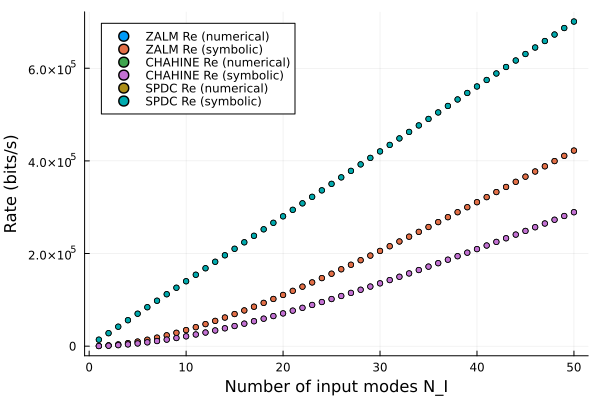

In [34]:
function plot_rate_dist_entanglement_with_Nm()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ_zalm = 0.0173
    μ_chahine = 0.0263
    μ_spdc = 0.00694
    ηR = 0.01
    ηT = 0.9
    Rp = 10e9
    N_I = collect(1:50)
    N_M = N_I
    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ_zalm, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine) 
    zalm_rates_symbolic = zalm_rate_dist_entanglement_symbolic.(μ_zalm, ηR, ηT, Rp, N_I, N_M)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ_chahine, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)
    chahine_rates_symbolic = chahine_rate_dist_entanglement_symbolic.(μ_chahine, ηR, ηT, Rp, N_I, N_M)
    
    spdc_rates_numerical = [spdc_rate_dist_entanglement_numerical(μ_spdc, ηR, Rp, N_M_i; engine=spdc_engine) for N_M_i in N_M]
    spdc_rates_symbolic = [spdc_rate_dist_entanglement_symbolic(μ_spdc, ηR, Rp, N_M_i) for N_M_i in N_M]

    Plots.plot(N_I, zalm_rates_numerical, seriestype=:scatter, label="ZALM Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", legend=:topleft,color=1, markersize=3)
    Plots.plot!(N_I, zalm_rates_symbolic, seriestype=:scatter, label="ZALM Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)",color=2, markersize=3)
    Plots.plot!(N_I, chahine_rates_numerical, seriestype=:scatter, label="CHAHINE Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=3, markersize=3)
    Plots.plot!(N_I, chahine_rates_symbolic, seriestype=:scatter, label="CHAHINE Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=4, markersize=3)
    Plots.plot!(N_I, spdc_rates_numerical, seriestype=:scatter, label="SPDC Re (numerical)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=5, markersize=3)
    Plots.plot!(N_I, spdc_rates_symbolic, seriestype=:scatter, label="SPDC Re (symbolic)", xlabel="Number of input modes N_I", ylabel="Rate (bits/s)", color=6, markersize=3)
end
@time plot_rate_dist_entanglement_with_Nm()


Rate of distribuited entanglement exploration

For ther porpuse pof this analysis, we will consider the effects of error and mean photon number parameters of the entanglement source.

  0.467561 seconds (648.85 k allocations: 294.593 MiB, 13.11% gc time, 4.79% compilation time)


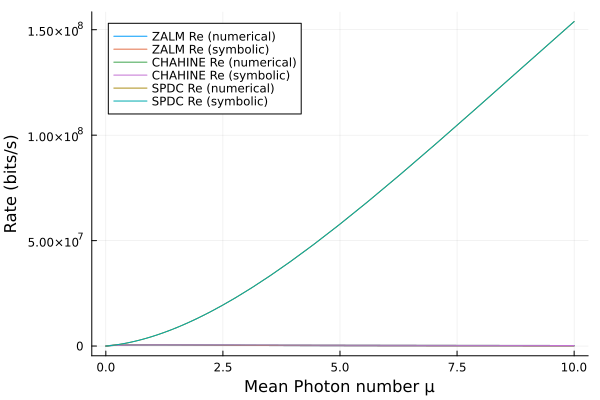

In [35]:
function plot_rate_dist_entanglement_vs_μ()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ = logrange(1e-4, 10, 100)
    ηR = 0.01
    ηT = 0.9
    Rp = 10e9
    N_I = 10
    N_M = 1

    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine)
    zalm_rates_symbolic = zalm_rate_dist_entanglement_symbolic.(μ, ηR, ηT, Rp, N_I, N_M)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)
    chahine_rates_symbolic = chahine_rate_dist_entanglement_symbolic.(μ, ηR, ηT, Rp, N_I, N_M)
    
    spdc_rates_numerical = spdc_rate_dist_entanglement_numerical.(μ, ηR, Rp, N_M; engine=spdc_engine)
    spdc_rates_symbolic = spdc_rate_dist_entanglement_symbolic.(μ, ηR, Rp, N_M)

    Plots.plot(μ, zalm_rates_numerical, label="ZALM Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", legend=:topleft,color=1, markersize=2)
    Plots.plot!(μ, zalm_rates_symbolic, label="ZALM Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)",color=2, markersize=2)
    Plots.plot!(μ, chahine_rates_numerical, label="CHAHINE Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=3, markersize=2)
    Plots.plot!(μ, chahine_rates_symbolic, label="CHAHINE Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=4, markersize=2)
    Plots.plot!(μ, spdc_rates_numerical, label="SPDC Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=5, markersize=2)
    Plots.plot!(μ, spdc_rates_symbolic, label="SPDC Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=6, markersize=2)
end
@time plot_rate_dist_entanglement_vs_μ()

In [36]:
function plot_rate_dist_entanglement_vs_ηₜ()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ_zalm = 0.0173
    μ_chahine = 0.0263
    μ_spdc = 0.00694
    ηR = 0.01
    ηT = logrange(0.7, 1, 100)
    Rp = 10e9
    N_I = 10
    N_M = 1

    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ_zalm, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine)
    zalm_rates_symbolic = zalm_rate_dist_entanglement_symbolic.(μ_zalm, ηR, ηT, Rp, N_I, N_M)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ_chahine, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)
    chahine_rates_symbolic = chahine_rate_dist_entanglement_symbolic.(μ_chahine, ηR, ηT, Rp, N_I, N_M)
    
    spdc_rates_numerical = spdc_rate_dist_entanglement_numerical.(μ_spdc, ηR, Rp, N_M; engine=spdc_engine)
    spdc_rates_symbolic = spdc_rate_dist_entanglement_symbolic.(μ_spdc, ηR, Rp, N_M)

    Plots.plot(ηT, zalm_rates_numerical, label="ZALM Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", legend=:topleft,color=1, markersize=2)
    Plots.plot!(ηT, zalm_rates_symbolic, label="ZALM Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)",color=2, markersize=2)
    Plots.plot!(ηT, chahine_rates_numerical, label="CHAHINE Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=3, markersize=2)
    Plots.plot!(ηT, chahine_rates_symbolic, label="CHAHINE Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=4, markersize=2)
    Plots.plot!(ηT, spdc_rates_numerical, label="SPDC Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=5, markersize=2)
    Plots.plot!(ηT, spdc_rates_symbolic, label="SPDC Re (symbolic)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", color=6, markersize=2)
end
@time plot_rate_dist_entanglement_vs_ηₜ()

ErrorException: Cannot convert Float64 to series data for plotting

  0.467255 seconds (458.20 k allocations: 252.346 MiB, 11.13% gc time)


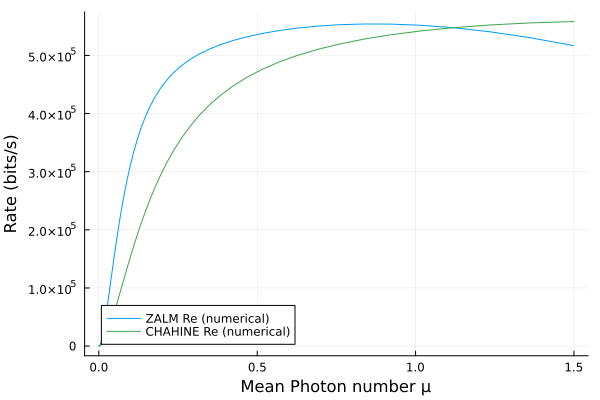

In [37]:
function plot_rate_dist_entanglement_with_Nm()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)
    μ = logrange(1e-4, 1.5, 100)
    ηR = 0.01
    ηT = 0.9
    Rp = 10e9
    N_I = 10
    N_M = 1

    zalm_rates_numerical = zalm_rate_dist_entanglement_numerical.(μ, ηR, ηT, Rp, N_I, N_M; engine=zalm_engine)

    chahine_rates_numerical = chahine_rate_dist_entanglement_numerical.(μ, ηR, ηT, Rp, N_I, N_M; engine=chahine_engine)

    Plots.plot(μ, zalm_rates_numerical, label="ZALM Re (numerical)", xlabel="Mean Photon number μ", ylabel="Rate (bits/s)", legend=:bottomleft,color=1)
    
    Plots.plot!(μ, chahine_rates_numerical, label="CHAHINE Re (numerical)", color=3)
end
@time plot_rate_dist_entanglement_with_Nm()


So far this has been useful to model the base paper, Now with the use of Genqo one can model a diferent number of loss parameters.
specifically it is interesting to note that the probability of heralding for the chahine source decays slower than zalm. and zalm has higher probability of heralding only for mean photon number < 0.7 (TODO: CHECK ACTUAL NUMBER) so we can explore the results for a mean photon number that 

In [38]:
function plot_Pherald_comparison()
    engine_zalm = HybridProjectionEngine(8)
    engine_chahine = HybridProjectionEngine(6)
    μ = logrange(1e-4, 10, 100)

    ηR = 0.01
    ηT = 0.9

    PH_zalm_numerical = zalm_PHeralded_symbolic.(μ, ηR, ηT; engine=engine_zalm)
    PH_zalm_symbolic = zalm_PHeralded_symbolic.(μ, ηR, ηT)

    PH_chahine_numerical = chahine_PHeralded_numerical.(μ, ηR, ηT; engine=engine_chahine)
    PH_chahine_symbolic = chahine_PHeralded_symbolic.(μ, ηR, ηT)

    Plots.plot(μ, PH_zalm_symbolic, label = "ZALM analytic", xlabel = "Mean Photon Number",ylabel = "Heralding Probability", legend = :topright,color = 1)
    Plots.plot!(μ, PH_chahine_symbolic, label = "Chahine analytic", color = 3)
    Plots.plot!(μ, PH_zalm_numerical, label = "ZALM numerical (Genqo v2.0)", color = 2, linestyle = :dash)
    Plots.plot!(μ, PH_chahine_numerical, label = "Chahine numerical (Genqo v2.0)", color = 5, linestyle = :dash)
    Plots.title!("Heralding Probability Comparison for: \$\\eta_R = $(ηR),\\; \\eta_T = $(ηT)\$")
end
@time plot_Pherald_comparison()

MethodError: MethodError: no method matching zalm_PHeralded_symbolic(::Float64, ::Float64, ::Float64; engine::HybridProjectionEngine)
This method does not support all of the given keyword arguments (and may not support any).

Closest candidates are:
  zalm_PHeralded_symbolic(::Float64, ::Float64, ::Float64) got unsupported keyword argument "engine"
   @ Main ~/vscode/Genqo.jl/docs/tutorial/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X43sdnNjb2RlLXJlbW90ZQ==.jl:1


### Parameterize over $\mu$

In [39]:
function plot_comprehensive_comparison()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)

    μ_range = range(1e-4, 10, 100)
    ηR = 0.01
    N_I = 10
    ηT_mid = 0.9
    Rp = 10e9
    N_I = 10
    N_M = 1

    # ===== Plot 1: Loading Probability vs μ =====
    p1_zalm_load = zalm_Pload_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine) ./ zalm_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine) .* 4
    p1_chahine_load = chahine_Pload_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine) ./ chahine_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine)
    p1_spdc_load = spdc_Pload_numerical.(μ_range, ηR; engine=spdc_engine)
    p1_zalm_load_analytic = zalm_Pload_symbolic.(μ_range, ηR, ηT_mid)
    p1_chahine_load_analytic = chahine_Pload_symbolic.(μ_range, ηR, ηT_mid)

    p1 = Plots.plot(μ_range, p1_zalm_load, label="ZALM", xlabel="μ", ylabel="Loading Probability", color=1, legend=:bottomright)
    Plots.plot!(μ_range, p1_chahine_load, label="Chahine", color=3)
    Plots.plot!(μ_range, p1_zalm_load_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(μ_range, p1_chahine_load_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   # Plots.plot!(μ_range, p1_spdc_load, label="SPDC", color=5)
    Plots.title!("Loading Probability vs μ (ηT=$(ηT_mid))")

    # ===== Plot 2: Bell Probability vs μ =====
    p2_zalm_bell = zalm_Pbell_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine) ./ zalm_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine) .* 4
    p2_chahine_bell = chahine_Pbell_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine) ./ chahine_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine)
    p2_spdc_bell = spdc_Pbell_numerical.(μ_range, ηR; engine=spdc_engine)
    p2_zalm_bell_analytic = zalm_Pbell_symbolic.(μ_range, ηR, ηT_mid)
    p2_chahine_bell_analytic = chahine_Pbell_symbolic.(μ_range, ηR, ηT_mid)
    
    p2 = Plots.plot(μ_range, p2_zalm_bell, label="ZALM", xlabel="μ", ylabel="Bell Probability", color=1, legend=:bottomright)
    Plots.plot!(μ_range, p2_chahine_bell, label="Chahine", color=3)
    Plots.plot!(μ_range, p2_zalm_bell_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(μ_range, p2_chahine_bell_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   #Plots.plot!(μ_range, p2_spdc_bell, label="SPDC", color=5)
    Plots.title!("Bell Probability vs μ (ηT=$(ηT_mid))")

    # ===== Plot 3: E_H() vs μ =====
    p3_zalm_eh = E_H.(p_k_array.(N_I, sqrt.(zalm_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine))), N_I)
    p3_chahine_eh = E_H.(p_k_array.(N_I, sqrt.(chahine_PHeralded_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine))), N_I)

    p3 = Plots.plot(μ_range, p3_zalm_eh, label="ZALM", xlabel="μ", ylabel="E_H()", color=1, legend=:topright)
    Plots.plot!(μ_range, p3_chahine_eh, label="Chahine", color=3)
    Plots.title!("E_H() vs μ (N_I=$N_I, ηT=$(ηT_mid))")

    # ===== Plot 4: Rate of Distributed Entanglement vs μ =====
    p4_zalm_rate = zalm_rate_dist_entanglement_numerical.(μ_range, ηR, ηT_mid, Rp, N_I, N_I; engine=zalm_engine)
    p4_chahine_rate = chahine_rate_dist_entanglement_numerical.(μ_range, ηR, ηT_mid, Rp, N_I, N_I; engine=chahine_engine)
    p4_spdc_rate = spdc_rate_dist_entanglement_numerical.(μ_range, ηR, Rp, N_I; engine=spdc_engine)
    p4_zalm_rate_analytic = zalm_rate_dist_entanglement_symbolic.(μ_range, ηR, ηT_mid, Rp, N_I, N_I)
    p4_chahine_rate_analytic = chahine_rate_dist_entanglement_symbolic.(μ_range, ηR, ηT_mid, Rp, N_I, N_I)

    p4 = Plots.plot(μ_range, p4_zalm_rate, label="ZALM", xlabel="μ", ylabel="Rate (bits/s)", color=1, legend=:topright)
    Plots.plot!(μ_range, p4_chahine_rate, label="Chahine", color=3)
    Plots.plot!(μ_range, p4_zalm_rate_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(μ_range, p4_chahine_rate_analytic, label="Chahine analytic", color=4, linestyle=:dash)
    Plots.title!("Rate Distributed entanglement vs μ (ηT=$(ηT_mid))")

    # ===== Plot 5: Fidelity vs μ =====
    p5_zalm_fidelity = zalm_bell_fidelity_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine)
    p5_chahine_fidelity = chahine_bell_fidelity_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine)
    p5_spdc_fidelity = spdc_bell_fidelity_numerical.(μ_range, ηR; engine=spdc_engine)
    p5_zalm_fidelity_analytic = zalm_bell_fidelity_symbolic.(μ_range, ηR, ηT_mid)
    p5_chahine_fidelity_analytic = chahine_bell_fidelity_symbolic.(μ_range, ηR, ηT_mid)
    p5_spdc_fidelity_analytic = spdc_bell_fidelity_symbolic.(μ_range, ηR)

    p5 = Plots.plot(μ_range, p5_zalm_fidelity, label="ZALM", xlabel="μ", ylabel="Fidelity", color=1, legend=:topright)
    Plots.plot!(μ_range, p5_chahine_fidelity, label="Chahine", color=3)
   # Plots.plot!(μ_range, p5_spdc_fidelity, label="SPDC", color=5)
    Plots.plot!(μ_range, p5_zalm_fidelity_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(μ_range, p5_chahine_fidelity_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   # Plots.plot!(μ_range, p5_spdc_fidelity_analytic, label="SPDC analytic", color=6, linestyle=:dash)
     Plots.title!("Bell Fidelity vs μ (ηT=$(ηT_mid))")

    # ===== Plot 6: Bell Fraction vs μ =====
    p6_zalm_bell_fraction = zalm_Pbell_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine) ./ zalm_Pload_numerical.(μ_range, ηR, ηT_mid; engine=zalm_engine)
    p6_zalm_bell_fraction_symbolic = zalm_bell_fraction_symbolic.(μ_range, ηR, ηT_mid)
    p6_chahine_bell_fraction = chahine_Pbell_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine) ./ chahine_Pload_numerical.(μ_range, ηR, ηT_mid; engine=chahine_engine)
    p6_chahine_bell_fraction_symbolic = chahine_bell_faction_symbolic.(μ_range, ηR, ηT_mid)

    P6 = Plots.plot(μ_range, p6_zalm_bell_fraction, label="ZALM", xlabel="μ", ylabel="Bell Fraction", color=1, legend=:topright)
    Plots.plot!(μ_range, p6_zalm_bell_fraction_symbolic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(μ_range, p6_chahine_bell_fraction, label="Chahine", color=3)
    Plots.plot!(μ_range, p6_chahine_bell_fraction_symbolic, label="Chahine analytic", color=4, linestyle=:dash)
    Plots.title!("Bell Fraction vs μ (ηT=$(ηT_mid))")
   # Plots.plot!(
    # Combine all plots
   Plots.plot(p1, p2, p3, p4, p5, P6, layout=(2, 3), size=(1400, 1000))
end

@time plot_comprehensive_comparison()
savefig("myplot.png")
savefig("myplot.svg")

  2.234276 seconds (2.33 M allocations: 895.051 MiB, 30.38% gc time, 21.63% compilation time: 42% of which was recompilation)


"/home/jorge/vscode/Genqo.jl/docs/tutorial/myplot.svg"

### Parameterize over $\eta_T$

In [40]:
function plot_comprehensive_comparison_transmissivity()
    zalm_engine = HybridProjectionEngine(8)
    chahine_engine = HybridProjectionEngine(6)
    spdc_engine = HybridProjectionEngine(4)

    μ_zalm = 3.0
    μ_chahine = 3.0
    μ_spdc = 3.0
    ηR = 0.01
    N_I = 10
    ηT = logrange(0.7, 1, 100)
    Rp = 10e9
    N_I = 10
    N_M = 1

    # ===== Plot 1: Loading Probability vs μ =====
    p1_zalm_load = zalm_Pload_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine) ./ zalm_PHeralded_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine) .* 4
    p1_chahine_load = chahine_Pload_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine) ./ chahine_PHeralded_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine)
    p1_spdc_load = spdc_Pload_numerical.(μ_spdc, ηR; engine=spdc_engine)
    p1_zalm_load_analytic = zalm_Pload_symbolic.(μ_zalm, ηR, ηT)
    p1_chahine_load_analytic = chahine_Pload_symbolic.(μ_chahine, ηR, ηT)

    p1 = Plots.plot(ηT, p1_zalm_load, label="ZALM", xlabel="ηT", ylabel="Loading Probability", color=1, legend=:topright)
    Plots.plot!(ηT, p1_chahine_load, label="Chahine", color=3)
    Plots.plot!(ηT, p1_zalm_load_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(ηT, p1_chahine_load_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   # Plots.plot!(ηT, p1_spdc_load, label="SPDC", color=5)
    Plots.title!("Loading Probability vs ηT")

    # ===== Plot 2: Bell Probability vs μ =====
    p2_zalm_bell = zalm_Pbell_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine) ./ zalm_PHeralded_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine) .* 4
    p2_chahine_bell = chahine_Pbell_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine) ./ chahine_PHeralded_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine)
    p2_spdc_bell = spdc_Pbell_numerical.(μ_spdc, ηR; engine=spdc_engine)
    p2_zalm_bell_analytic = zalm_Pbell_symbolic.(μ_zalm, ηR, ηT)
    p2_chahine_bell_analytic = chahine_Pbell_symbolic.(μ_chahine, ηR, ηT)
    
    p2 = Plots.plot(ηT, p2_zalm_bell, label="ZALM", xlabel="ηT", ylabel="Bell Probability", color=1, legend=:topright)
    Plots.plot!(ηT, p2_chahine_bell, label="Chahine", color=3)
    Plots.plot!(ηT, p2_zalm_bell_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(ηT, p2_chahine_bell_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   #Plots.plot!(ηT, p2_spdc_bell, label="SPDC", color=5)
    Plots.title!("Bell Probability vs ηT")

    # ===== Plot 3: E_H() vs μ =====
    p3_zalm_eh = E_H.(p_k_array.(N_I, sqrt.(zalm_PHeralded_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine))), N_I)
    p3_chahine_eh = E_H.(p_k_array.(N_I, sqrt.(chahine_PHeralded_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine))), N_I)

    p3 = Plots.plot(ηT, p3_zalm_eh, label="ZALM", xlabel="ηT", ylabel="E_H()", color=1, legend=:topright)
    Plots.plot!(ηT, p3_chahine_eh, label="Chahine", color=3)
    Plots.title!("E_H() vs ηT")

    # ===== Plot 4: Rate of Distributed Entanglement vs μ =====
    p4_zalm_rate = zalm_rate_dist_entanglement_numerical.(μ_zalm, ηR, ηT, Rp, N_I, N_I; engine=zalm_engine)
    p4_chahine_rate = chahine_rate_dist_entanglement_numerical.(μ_chahine, ηR, ηT, Rp, N_I, N_I; engine=chahine_engine)
    p4_spdc_rate = spdc_rate_dist_entanglement_numerical.(μ_spdc, ηR, Rp, N_I; engine=spdc_engine)
    p4_zalm_rate_analytic = zalm_rate_dist_entanglement_symbolic.(μ_zalm, ηR, ηT, Rp, N_I, N_I)
    p4_chahine_rate_analytic = chahine_rate_dist_entanglement_symbolic.(μ_chahine, ηR, ηT, Rp, N_I, N_I)

    p4 = Plots.plot(ηT, p4_zalm_rate, label="ZALM", xlabel="ηT", ylabel="Rate (bits/s)", color=1, legend=:topright)
    Plots.plot!(ηT, p4_chahine_rate, label="Chahine", color=3)
    Plots.plot!(ηT, p4_zalm_rate_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(ηT, p4_chahine_rate_analytic, label="Chahine analytic", color=4, linestyle=:dash)
    Plots.title!("Rate Distributed entanglement vs ηT")

    # ===== Plot 5: Fidelity vs μ =====
    p5_zalm_fidelity = zalm_bell_fidelity_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine)
    p5_chahine_fidelity = chahine_bell_fidelity_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine)
    p5_spdc_fidelity = spdc_bell_fidelity_numerical.(μ_spdc, ηR; engine=spdc_engine)
    p5_zalm_fidelity_analytic = zalm_bell_fidelity_symbolic.(μ_zalm, ηR, ηT)
    p5_chahine_fidelity_analytic = chahine_bell_fidelity_symbolic.(μ_chahine, ηR, ηT)
    p5_spdc_fidelity_analytic = spdc_bell_fidelity_symbolic.(μ_spdc, ηR)

    p5 = Plots.plot(ηT, p5_zalm_fidelity, label="ZALM", xlabel="ηT", ylabel="Fidelity", color=1, legend=:topleft)
    Plots.plot!(ηT, p5_chahine_fidelity, label="Chahine", color=3)
   # Plots.plot!(ηT, p5_spdc_fidelity, label="SPDC", color=5)
    Plots.plot!(ηT, p5_zalm_fidelity_analytic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(ηT, p5_chahine_fidelity_analytic, label="Chahine analytic", color=4, linestyle=:dash)
   # Plots.plot!(ηT, p5_spdc_fidelity_analytic, label="SPDC analytic", color=6, linestyle=:dash)
     Plots.title!("Bell Fidelity vs ηT")

    # ===== Plot 6: Bell Fraction vs μ =====
    p6_zalm_bell_fraction = zalm_Pbell_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine) ./ zalm_Pload_numerical.(μ_zalm, ηR, ηT; engine=zalm_engine)
    p6_zalm_bell_fraction_symbolic = zalm_bell_fraction_symbolic.(μ_zalm, ηR, ηT)
    p6_chahine_bell_fraction = chahine_Pbell_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine) ./ chahine_Pload_numerical.(μ_chahine, ηR, ηT; engine=chahine_engine)
    p6_chahine_bell_fraction_symbolic = chahine_bell_faction_symbolic.(μ_chahine, ηR, ηT)

    P6 = Plots.plot(ηT, p6_zalm_bell_fraction, label="ZALM", xlabel="ηT", ylabel="Bell Fraction", color=1, legend=:topleft)
    Plots.plot!(ηT, p6_zalm_bell_fraction_symbolic, label="ZALM analytic", color=2, linestyle=:dash)
    Plots.plot!(ηT, p6_chahine_bell_fraction, label="Chahine", color=3)
    Plots.plot!(ηT, p6_chahine_bell_fraction_symbolic, label="Chahine analytic", color=4, linestyle=:dash)
    Plots.title!("Bell Fraction vs ηT")
   # Plots.plot!(
    # Combine all plots
   Plots.plot(p1, p2, p3, p4, p5, P6, layout=(2, 3), size=(1400, 1000))
end

@time plot_comprehensive_comparison_transmissivity()
savefig("myplot.png")
savefig("myplot.svg")

  0.879705 seconds (1.20 M allocations: 764.787 MiB, 14.51% gc time)


"/home/jorge/vscode/Genqo.jl/docs/tutorial/myplot.svg"

## Entanglement destilation